In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from utils import train_ensemble_poisson_regressor

## 1. Get data

In [4]:
username = 'rodrigo'
host = 'localhost'           
port = '5432'               
database = 'futmondo_full_players_info'

engine = create_engine(f'postgresql+psycopg2://{username}@{host}:{port}/{database}')
# query = "SELECT * FROM full_training_data"
query= """SELECT *
    FROM full_training_data;"""

df = pd.read_sql(query, engine)
df.shape

(7363, 39)

In [5]:
df_yamal=df[df['name']=='Lamine Yamal']

In [6]:
df_yamal[['round', 'target_points']]

,round,target_points
333,13,11.0
857,14,7.0
1325,15,9.0
1892,16,9.0
2435,17,7.0
2946,18,12.0
3468,19,5.0
3982,20,12.0
4506,21,14.0
5033,22,14.0


In [7]:
df['round'].max()

np.int64(26)

In [8]:
engine = create_engine(f'postgresql+psycopg2://{username}@{host}:{port}/{database}')
# query = "SELECT * FROM full_training_data"
query= """SELECT *
    FROM player_points_def;"""

player_points = pd.read_sql(query, engine)
player_points.shape

(7363, 17)

In [9]:
player_points.columns

Index(['player_id', 'name', 'role', 'round', 'team_id', 'home_average',
       'away_average', 'overall_average', 'current_price', 'matches_played',
       'rating', 'match_minus_1', 'match_minus_2', 'last_2_average',
       'target_points', 'unique_id', 'team'],
      dtype='object')

In [10]:
# df=pd.read_csv('data/final_dataset/futmondo_final_dataset.csv')
# df.shape

## 2. Build the model

Features to eliminate in this second iteration:
- They are too decisive for the model: price-related values.
- They are not adding any new information compared with other features.

Features to eliminate: current_price, price_per_point, overall_average (too historical), match_minus_1, match_minus_2 (already captured by last_2_average or form_trend), matchup_prob_draw (Social scoring, draws are "neutral -> adds no real value)

In [11]:
# Corrected feature columns
feature_columns = [
    'home_average',
    'away_average', 
    'rating',    
    # 'overall_average', 
    'last_2_average', 
    # 'current_price',
    'is_home',
    # 'match_minus_1',
    # 'match_minus_2',  
    'matchup_prob_win', 
    # 'matchup_prob_draw', 
    'matchup_prob_loss', 
    'form_trend', 
    'home_away_diff', 
    # 'price_per_point',  
    'recent_momentum', 
    'home_form_interaction',
    'away_form_interaction',
    'location_adjusted_average',  
    'matchup_strength',
    'team_expected_performance', 
    'delantero_matchup_bonus',
    'centrocampista_matchup_bonus', 
    'defensa_matchup_bonus',
    'portero_matchup_bonus', 
    'home_matchup_boost', 
    'difficult_matchup',
    'easy_matchup'
]

In [12]:
# # A. The "Winner's Halo" (Interaction Feature). Journalists rarely give high ratings to losing teams. We need to boost players whose team is expected to dominate.
# df['win_form_interaction'] = df['last_2_average'] * df['matchup_prob_win']
# # The "Media Darling" Bias. Being at home often leads to better ratings.
# df['home_star_bias'] = df['is_home'] * df['rating']
# # The "Clean Sheet" Potential (For Defenders/GKs)
# df['defensive_potential'] = df['easy_matchup'] * df['defensa_matchup_bonus']

In [13]:
# # Optimized Feature Columns for "Social" Scoring
# feature_columns = [
#     # --- FORM (The most important factor) ---
#     'last_2_average',
#     'form_trend',
#     'recent_momentum',
    
#     # --- THE MATCHUP (Context) ---
#     'matchup_strength',
#     'matchup_prob_win',       # Keep Win, Drop Draw
#     'matchup_prob_loss',      # High loss prob = risk of negative points
#     'team_expected_performance',
#     'home_away_diff',
#     'is_home',
    
#     # --- POSITION SPECIFIC (Crucial for rules) ---
#     'delantero_matchup_bonus',
#     'centrocampista_matchup_bonus',
#     'defensa_matchup_bonus',
#     'portero_matchup_bonus',
    
#     # --- NEW "PSYCHOLOGY" FEATURES (The Strategy 1 additions) ---
#     'win_form_interaction',   # (Make sure to calculate this first!)
#     'home_star_bias',         # (Make sure to calculate this first!)
#     'defensive_potential',    # (Make sure to calculate this first!)
    
#     # --- RETAINED USEFUL METRICS ---
#     'rating',                 # Keep: Base quality indicator
#     'location_adjusted_average' # Keep: Good for players who only perform at home
# ]

In [15]:
df.head(2)

,player_id,name,role,round,team_id,home_average,away_average,overall_average,current_price,matches_played,...,location_adjusted_average,matchup_strength,team_expected_performance,delantero_matchup_bonus,centrocampista_matchup_bonus,defensa_matchup_bonus,portero_matchup_bonus,home_matchup_boost,difficult_matchup,easy_matchup
0,52013ee178b20d7f07000351,Josan,centrocampista,13,51b889b1e401a15f2c0000f0,4.400000,1.50,3.571429,1000000,7,...,4.400000,-0.570438,0.555189,0.0,0.150752,0.0,0.00000,0.062813,1,0
1,521a999b5865e5687000001c,David Soria,portero,13,504e581e4d8bec9a670000cd,7.571429,3.75,5.533333,20975958,15,...,7.571429,-0.355844,0.828432,0.0,0.000000,0.0,0.68982,0.092138,1,0


In [33]:
# Drop rows where target_points or any feature is NaN
df_clean = df.dropna(subset=['target_points'] + feature_columns)
X = df_clean[feature_columns]
y = df_clean['target_points']

In [34]:
df_clean.shape

(6433, 39)

In [37]:
model, scaler, metrics, fi_df=train_ensemble_poisson_regressor(
    X, 
    y, 
    feature_columns,
    test_size=0.2,
    offset=10,
    random_state=42,
    hgb_params=None,
    lgbm_params=None,
    rf_params=None,
    voting_weights=[2, 2, 1],
    show_plot=True
)

/Users/rodrigo/football-data-analytics/futmondo_points_predict/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rodrigo/football-data-analytics/futmondo_points_predict/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rodrigo/football-data-analytics/futmondo_points_predict/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rodrigo/football-data-analytics/futmondo_points_predict/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rodri

In [38]:
metrics

{'mae': 1.8065354827537428,
 'rmse': np.float64(2.745386451652775),
 'r2': 0.3000756918531121}

In [39]:
import joblib

model_package = {
    'model': model,
    'scaler': scaler,
    'feature_columns': feature_columns}

joblib.dump(model_package, '../data/model/fantasy_model_complete.pkl')

['../data/model/fantasy_model_complete.pkl']

In [17]:
# # Check for NaN values first
# print("NaN values per column:")
# print(X.isna().sum())
# print(f"\nTotal NaN values: {X.isna().sum().sum()}")

# # Option 1: Drop rows with NaN values (if not too many)
# X_clean = X.dropna()
# y_clean = y[X_clean.index]

# print(f"\nRows before: {len(X)}, Rows after: {len(X_clean)}")

### 2. Model training. First iteration

/Users/rodrigo/football-data-analytics/futmondo_points_predict/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rodrigo/football-data-analytics/futmondo_points_predict/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rodrigo/football-data-analytics/futmondo_points_predict/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rodrigo/football-data-analytics/futmondo_points_predict/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rodri

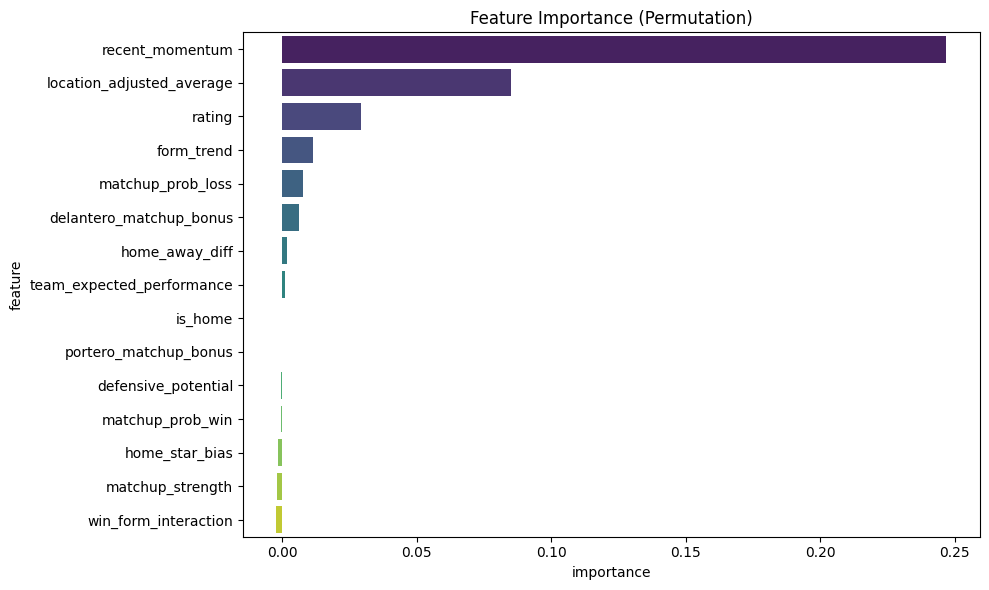

In [18]:
model, scaler, metrics, fi_df=train_ensemble_poisson_regressor(
    X, 
    y, 
    feature_columns,
    test_size=0.2,
    offset=10,
    random_state=42,
    hgb_params=None,
    lgbm_params=None,
    rf_params=None,
    voting_weights=[2, 2, 1],
    show_plot=True
)

In [ ]:
import joblib

model_package = {
    'model': model,
    'scaler': scaler,
    'feature_columns': feature_columns}

joblib.dump(model_package, '../data/model/fantasy_model_complete.pkl')

: 

### 3. Second iteration. Get more features

Eliminate these features, they are having no impact on the prediction

In [44]:
# Drop these - they're adding noise:
'last_2_average'           # 0.00074 importance
'home_away_diff'           # 0.00109 importance  
'centrocampista_matchup_bonus'  # 0.00179 importance
'defensa_matchup_bonus'    # 0.00002 importance

'defensa_matchup_bonus'

In [45]:
df_clean.shape

(6433, 49)

In [46]:
df=df_clean.copy()

In [47]:
# Instead of just last_2_average, use:
df['last_3_weighted'] = (
    df['match_minus_1'] * 0.5 + 
    df['match_minus_2'] * 0.3 + 
    df['overall_average'] * 0.2  # Proxy for match_minus_3
)

df['form_volatility'] = np.abs(df['match_minus_1'] - df['match_minus_2'])

df['hot_streak'] = (df['match_minus_1'] > df['overall_average']).astype(int)

# Your recent_momentum is gold (0.274), so enhance it:
df['momentum_squared'] = df['recent_momentum'] ** 2  # Capture extreme momentum

In [48]:
# Instead of individual position bonuses (most are useless), do:
df['is_attacking'] = df['role'].isin(['Delantero', 'Centrocampista']).astype(int)

# Interaction features (these are FREE and powerful):
df['attacker_vs_weak_defense'] = (
    df['is_attacking'] * df['matchup_strength']  # Only delantero bonus mattered
)

df['star_home_game'] = (
    (df['rating'] > df['rating'].quantile(0.75)).astype(int) * 
    df['is_home'] * 
    df['matchup_prob_win']
)

In [49]:
new_feature_cols = [
    # === CORE FORM (Your Winners) ===
    # 'recent_momentum',              # 0.274 - Your MVP
    'momentum_squared',             # New - Capture extreme momentum
    'form_trend',                   # 0.043 - Solid
    'form_volatility',              # New - Consistency matters
    'hot_streak',                   # New - Binary momentum signal
    # 'weighted_recent_avg',          # Better than last_2_average
    
    # === PLAYER QUALITY ===
    'rating',                       # 0.033 - Base quality
    # 'location_adjusted_average',    # 0.120 - 2nd best feature
    
    # === MATCHUP CONTEXT ===
    'matchup_strength',             # 0.006 - Keep
    'matchup_prob_win',             # 0.008 - Win matters
    'matchup_prob_loss',            # 0.012 - Risk of disaster
    'team_expected_performance',    # 0.011 - Team context
    # 'opponent_defensive_rating',    # New data - keep it
    
    # === HOME/AWAY ===
    'is_home',                      # Binary flag
    'home_star_bias',               # 0.006 - Your engineered feature
    
    # === POSITION/ROLE ===
    'is_attacking',                 # New - Simpler than 4 position features
    'attacker_vs_weak_defense',     # New - Smart interaction
    'delantero_matchup_bonus',      # 0.011 - Only position bonus that worked
    
    # === KEY INTERACTIONS ===
    'star_home_game',               # New - Combines multiple signals
    'win_form_interaction',         # Your strategy feature
]

In [50]:
# Drop rows where target_points or any feature is NaN
df_clean = df.dropna(subset=['target_points'] + new_feature_cols)
X = df_clean[new_feature_cols]
y = df_clean['target_points']

/Users/rodrigo/football-data-analytics/futmondo_points_predict/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rodrigo/football-data-analytics/futmondo_points_predict/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rodrigo/football-data-analytics/futmondo_points_predict/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rodrigo/football-data-analytics/futmondo_points_predict/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/rodri

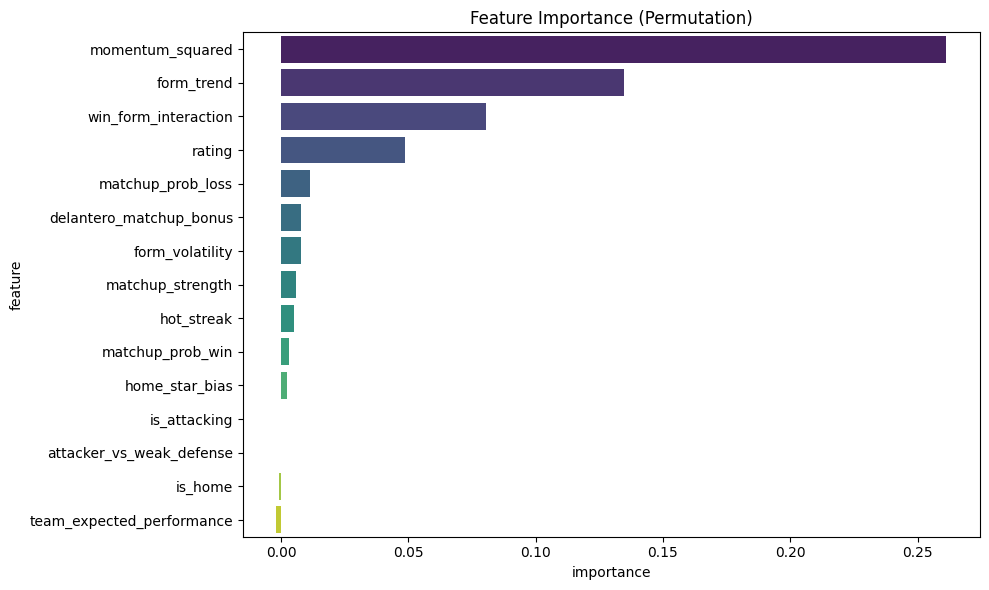

In [51]:
model, scaler, metrics, fi_df=train_ensemble_poisson_regressor(
    X, 
    y, 
    new_feature_cols,
    test_size=0.2,
    offset=10,
    random_state=42,
    hgb_params=None,
    lgbm_params=None,
    rf_params=None,
    voting_weights=[1.5, 1.5, 1],
    show_plot=True
)

In [52]:
metrics

{'mae': 1.81618977536865,
 'rmse': np.float64(2.751341481486111),
 'r2': 0.29703598090588534}

In [53]:
fi_df

,feature,importance,std_dev
0,momentum_squared,0.261328,0.018802
1,form_trend,0.134655,0.013871
15,win_form_interaction,0.080564,0.010964
4,rating,0.048792,0.008820
7,matchup_prob_loss,0.011492,0.005575
13,delantero_matchup_bonus,0.007989,0.003918
2,form_volatility,0.007719,0.005571
5,matchup_strength,0.005739,0.003086
3,hot_streak,0.004957,0.002672
6,matchup_prob_win,0.003154,0.004664


Save the model

In [54]:
import joblib

model_package = {
    'model': model,
    'scaler': scaler,
    'feature_columns': new_feature_cols}

joblib.dump(model_package, '../data/model/fantasy_model_complete.pkl')

['../data/model/fantasy_model_complete.pkl']